Naive Bayes Classifier for Budget Categorization.
This script uses a Naive Bayes classifier to categorize budget transactions based on their descriptions.


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Load and prepare the dataset while droping any unessesary catagories.

In [11]:
df = pd.read_csv("../DataHandling/cleaned_full_personal_finance.csv")
df = df[['Description', 'Category']].dropna()

# Rename for clarity
df = df.rename(columns={'Description': 'TransactionDescription', 'Category': 'FinalCategory'})
df['TransactionDescription'] = df['TransactionDescription'].str.lower().str.strip()

# Show the first few rows of the DataFrame
df[["TransactionDescription", "FinalCategory"]].head()


,TransactionDescription,FinalCategory
0,groceries at target,Groceries
1,groceries at walmart,Groceries
2,mcdonald's meal,Food & Dining
3,groceries at walmart,Groceries
4,spotify subscription,Entertainment


Preparation for the modeling

In [12]:
# Prepare inputs and labels
X = df["TransactionDescription"]
Y = df["FinalCategory"]

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


Using TF-idf to vectorize the text

In [13]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Training the model

In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Model evaluation

Classification Report:
               precision    recall  f1-score   support

    Education       1.00      1.00      1.00       140
Entertainment       1.00      1.00      1.00      4936
Food & Dining       1.00      1.00      1.00      2523
    Groceries       1.00      1.00      1.00      4941
   Healthcare       1.00      1.00      1.00       132
      Housing       1.00      1.00      1.00        61
     Shopping       1.00      1.00      1.00      2401
    Transport       1.00      1.00      1.00      4939
       Travel       1.00      1.00      1.00        63
    Utilities       1.00      1.00      1.00        64

     accuracy                           1.00     20200
    macro avg       1.00      1.00      1.00     20200
 weighted avg       1.00      1.00      1.00     20200



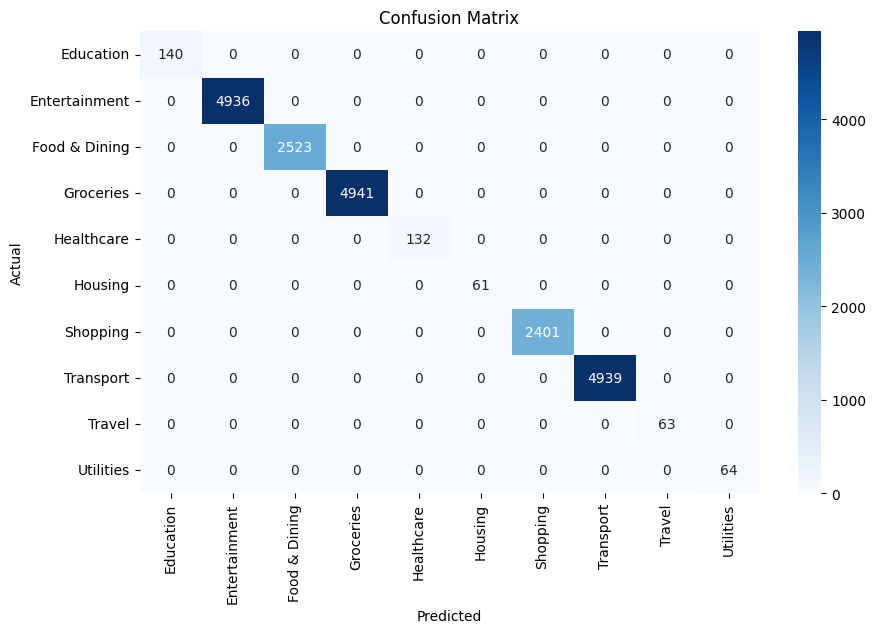

In [17]:
Y_pred = nb_model.predict(X_test_vec)

# Classification report
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
